In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

ticker='^N225' #The model is optimized with '^N225' but it's possible to use all the tickers
#IMPORT DATASET
try:
    # A) Try to download the data of the last 5 years from Yahoo Finance
    df_raw = yf.download(ticker, period='5y', progress=False)
    
    # Stop if data is empty
    if df_raw.empty:
        raise ValueError("Yahoo Finance has downloaded empty data")
    
    # Continue if data is not empty
    df = pd.DataFrame()
    df['Close'] = df_raw['Close']
    print(" Succcesful download from Yahoo Finance")

except Exception as e:
    # B) If there is some error in "try", the code uses the local dataset 
    print(f"Impossible to use Yahoo Finance ({e}).")
    print("Uploading local CSV...")
    
    # Uploud from local: It's possible to find an updated version at stooq.com (Ticker ^nkx)
    df = pd.read_csv('/Users/alessiocagnacci/Desktop/^nkx_d.csv', parse_dates=['Date'], index_col='Date')

#MANAGE DATASET
#Log return per 100 (The model suits better with higher value)
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))*100 

# Drop na column
df.dropna(subset=['Returns'], inplace=True)

# Standard deviation rolling evaluations, annualization (sqrt(252)) and 21 day shifting (Rolling volatility)
df['Target_Volatility'] = df['Returns'].rolling(window=21).std() * np.sqrt(252) 
df['Target_Volatility'] = df['Target_Volatility'].shift(-1)
# Lags creations
n_lags = 21
for i in range(1, n_lags + 1):
    df[f'Lag_{i}'] = df['Returns'].shift(i)

df.dropna(inplace=True)

# X and Y creations
feature_cols = [f'Lag_{i}' for i in range(1, n_lags + 1)]
X = df[feature_cols].values
y = df['Target_Volatility'].values

# Train/Test splitting for time series
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

YF.download() has changed argument auto_adjust default to True



1 Failed download:
['^N225']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Impossible to use Yahoo Finance (Yahoo Finance has downloaded empty data).
Uploading local CSV...
Train size: (958, 21), Test size: (240, 21)


/Users/alessiocagnacci/opt/anaconda3/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Training...
Kernel ottimizzato: 2.45**2 * RBF(length_scale=11.6) + WhiteKernel(noise_level=0.0128)
TESTING RESULTS
MAE  (Mean absolute error): 1.5444
RMSE (Radice mean quadratic error): 2.2129
Tail-RMSE (RMSE in 5% worst scenario): 4.2703
Directional Accuracy (MDA): 64.44%
Coverage Probability (expected ~95%): 95.83%


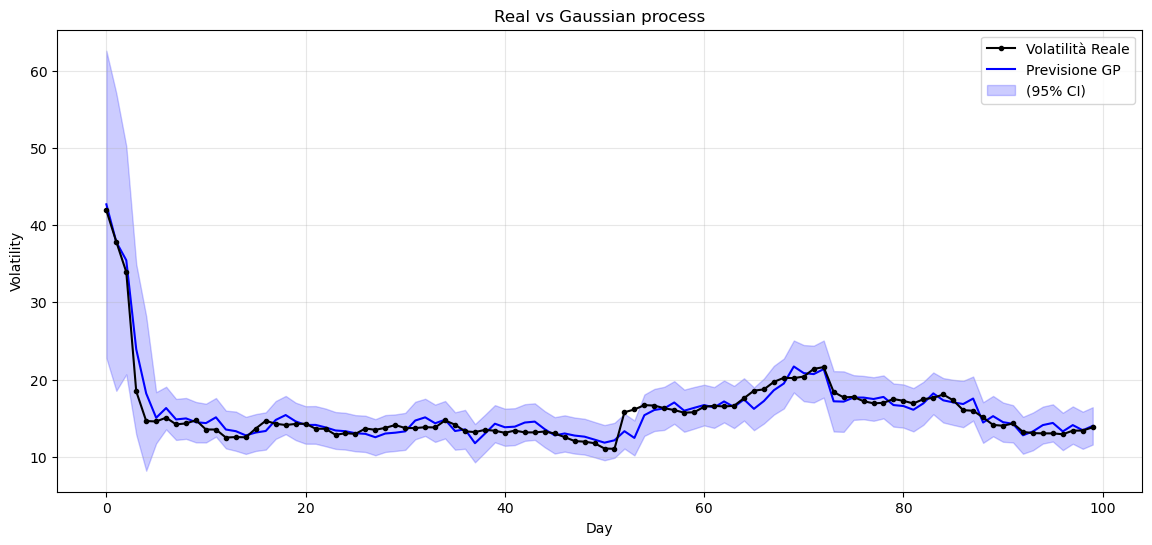

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
#  KERNEL RBF 
# C(): Volatility variations
# RBF(): Flexibility
# WhiteKernel(): with noise for financial time series

kernel = C(10, (1e-4, 1e4)) * RBF(length_scale=1.0, length_scale_bounds=(1e-4, 1e4)) \
         + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-8, 1e1))

# Algorithm of regression 

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    normalize_y=True,
    random_state=42
)

# TRAINING
print("Training...")
gp.fit(X_train, y_train)

# print the parameter chosen by GP
print(f"Kernel ottimizzato: {gp.kernel_}")

# Creating a prediction vector with standard deviation error
y_pred, sigma = gp.predict(X_test, return_std=True)

#TESTING

#Error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

#tail test
tail = np.percentile(y_test, 95)
data_tail = y_test >= tail
y_test_tail = y_test[data_tail]
y_pred_tail = y_pred[data_tail]

# RMSE in worst days scearious
tail_rmse = np.sqrt(mean_squared_error(y_test_tail, y_pred_tail))
print(f"TESTING RESULTS")
print(f"MAE  (Mean absolute error): {mae:.4f}")
print(f"RMSE (Radice mean quadratic error): {rmse:.4f}")
print(f"Tail-RMSE (RMSE in 5% worst scenario): {tail_rmse:.4f}")

#directional accuration
diff_real = np.diff(y_test)
diff_prev = np.diff(y_pred)

# How many times the direction was correct
correct = np.sign(diff_real) == np.sign(diff_prev)
#mean
mda = np.mean(correct)*100 
print(f"Directional Accuracy (MDA): {mda:.2f}%")

# Coverage Gaussian process
lower_bound = y_pred - 1.96 * sigma
upper_bound = y_pred + 1.96 * sigma

# How many times y_test in those interval
dentro_intervallo = (y_test >= lower_bound) & (y_test <= upper_bound)
#mean
coverage = np.mean(dentro_intervallo)*100 
print(f"Coverage Probability (expected ~95%): {coverage:.2f}%")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test[:100], label='Volatilità Reale', color='black', marker='.', zorder=3)
plt.plot(y_pred[:100], label='Previsione GP', color='blue', zorder=2)

# CI
plt.fill_between(
    range(100), 
    lower_bound[:100], 
    upper_bound[:100], 
    alpha=0.2, color='blue', label='(95% CI)', zorder=1
)

plt.title("Real vs Gaussian process")
plt.xlabel("Day")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [156]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

#CLASSIFICATION WITH RBF (SVC)
#REGIME OF VOLATILITY: Low, Normal, High, Extreme

#Manage dataset
cutoff = [0, 0.25, 0.75, 0.95, 1.0] 
labels = ['Low', 'Normal', 'High', 'Extreme']
df['Regime'] = pd.qcut(df['Target_Volatility'], q=cutoff, labels=labels)

# y for training
y_class = df['Regime'].values

# train and test splitting
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train_class, y_test_class = y_class[:split_index], y_class[split_index:]


#TRAINING
# probability=True gives the probability of risk
clf = SVC(kernel='rbf', C=5, gamma='scale', probability=True,class_weight='balanced', random_state=42)
print("Training...")
clf.fit(X_train, y_train_class)

#TESTING
y_pred = clf.predict(X_test)

# Classification Report (Precision, Recall, F1)
print("TESTING RESULTS")
print("Classification Report:")
print(classification_report(y_test_class, y_pred))

# Confusion matrix
print("Confusion matrix:")
cm = confusion_matrix(y_test_class, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"True {l}" for l in labels], columns=[f"Expected {l}" for l in labels])
print(cm_df)

Training...
TESTING RESULTS
Classification Report:
              precision    recall  f1-score   support

     Extreme       0.33      1.00      0.50         1
        High       0.30      0.33      0.32         9
         Low       0.85      0.97      0.90        93
      Normal       0.95      0.84      0.89       144

    accuracy                           0.87       247
   macro avg       0.61      0.79      0.65       247
weighted avg       0.88      0.87      0.87       247

Confusion matrix:
              Expected Low  Expected Normal  Expected High  Expected Extreme
True Low                90                3              0                 0
True Normal             16              121              7                 0
True High                0                4              3                 2
True Extreme             0                0              0                 1


In [157]:
#CLASSIFICATION WITH RBF (SVC)
#EXPECTED TREND

#Menage train and test set
X_dir = X #Original lag without np.abs

# Target: 1=Bullish, -1=Bearish
y_dir = np.where(df['Returns'] > 0, 1, -1)

# Split 
split_idx = int(len(X) * 0.8)

X_dir_train, X_dir_test = X_dir[:split_idx], X_dir[split_idx:]
y_dir_train, y_dir_test = y_dir[:split_idx], y_dir[split_idx:]

#TRAINING
mod_dir = SVC(kernel='rbf', C=1.6, gamma='scale', random_state=42) 
mod_dir.fit(X_dir_train, y_dir_train)

#TESTING
pred_dir = mod_dir.predict(X_dir_test)
#Classification report
print("TESTING RESULT")
print("Classification Report:")
print(classification_report(y_dir_test, pred_dir, target_names=['Up','Down']))
#Accuracy
acc_dir = accuracy_score(y_dir_test, pred_dir)

TESTING RESULT
Classification Report:
              precision    recall  f1-score   support

          Up       0.40      0.20      0.26        97
        Down       0.61      0.81      0.69       150

    accuracy                           0.57       247
   macro avg       0.50      0.50      0.48       247
weighted avg       0.52      0.57      0.52       247



In [158]:
#PREDICTION

# last 21 days used for prediction
last_days = df['Returns'].tail(21).values
X_today = last_days.reshape(1, -1)

# EXPECTED VOLATILITY WITH GP
volatility_tomorrow, err_tomorrow = gp.predict(X_today, return_std=True)

# Print the result
print(f"TOMORROW EXPECTATIONS FOR {ticker} ") 
print("-" * 45)
print("EXPECTED VOLATILITY")
print(f"Expected volatility: {volatility_tomorrow[0]:.2f}%")
print(f"Error: ± {err_tomorrow[0]:.2f}%")

# CI 95% 
inf = volatility_tomorrow[0] - (1.96 * err_tomorrow[0])
sup = volatility_tomorrow[0] + (1.96 * err_tomorrow[0])
print(f"Range di confidenza (95%): dal {inf:.2f}% al {sup:.2f}%")
print("-" * 45)

# REGIME PREDICTION WITH SVC
regime_predict = clf.predict(X_today)[0]
prob = clf.predict_proba(X_today)[0]

# Find probability for every regime 
classes = clf.classes_
prob_dict = dict(zip(classes, prob))

# Print results
print("PROBABILITY OF VOLATILITY REGIME")
print(f"Extreme high volatility:    {prob_dict['Extreme'] * 100:.1f}%")
print(f"High volatility:    {prob_dict['High'] * 100:.1f}%")
print(f"Normal volatility: {prob_dict['Normal'] * 100:.1f}%")
print(f"Very low volatility:   {prob_dict['Low'] * 100:.1f}%")
print("-" * 45)
print("REGIME PREDICTION")
print(f"Expected regime: {regime_predict.upper()} VOLATILITITY")

#EXPECTED TREND WITH SVC
exp_trend = mod_dir.predict(X_today)[0]
trend_str = "BULLISH" if exp_trend == 1 else "BEARISH"
#Print result
print("-" * 45)
print("TREND PREDICTION")
print(f"Expected trend: {trend_str}")
print(f"Accuracy: {acc_dir * 100:.2f}%")

TOMORROW EXPECTATIONS FOR ^IXIC 
---------------------------------------------
EXPECTED VOLATILITY
Expected volatility: 16.03%
Error: ± 1.35%
Range di confidenza (95%): dal 13.39% al 18.67%
---------------------------------------------
PROBABILITY OF VOLATILITY REGIME
Extreme high volatility:    0.2%
High volatility:    0.6%
Normal volatility: 81.3%
Very low volatility:   17.9%
---------------------------------------------
REGIME PREDICTION
Expected regime: NORMAL VOLATILITITY
---------------------------------------------
TREND PREDICTION
Expected trend: BULLISH
Accuracy: 56.68%
